In [ ]:
from sklearn.decomposition import PCA, FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/B-CODECRUNCH/spotify.csv")
data #print(data)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [ ]:
X = data[["tempo","valence","liveness","instrumentalness","acousticness","speechiness","mode","loudness","key","energy","danceability"]]
y = data["playlist_genre"]

In [ ]:
# sns.pairplot(data, hue="playlist_genre")

In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_encoded

array([2, 2, 2, ..., 0, 0, 0])

# Principal Component Analysis (PCA)

In [ ]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X)

In [ ]:
x_pca

array([[  1.19700656,   0.64141918],
       [-20.8995146 ,   5.58696131],
       [  3.16944436,  -4.33384527],
       ...,
       [  7.12565087,   0.66244923],
       [  7.16859228,  -3.35132368],
       [  7.12624029,  -0.33545007]])

Text(0.5, 1.0, 'PCA')

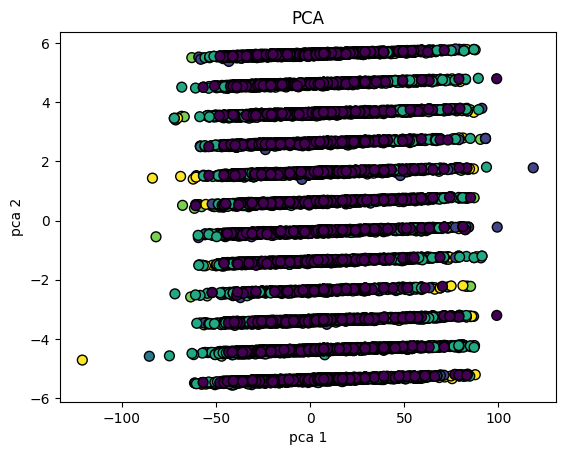

In [ ]:
plt.scatter(x_pca[:,0],x_pca[:,1],c=y_encoded,cmap="viridis",edgecolor="k",s=50)
plt.xlabel("pca 1")
plt.ylabel("pca 2")
plt.title("PCA")
# plt.show()

# Linear Discriminant Analysis (LDA)

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=2)
x_lda = lda.fit_transform(X,y_encoded)
pd.DataFrame(data=x_lda,columns=["lda 1","lda 2"])

,lda 1,lda 2
0,-0.123520,1.034576
1,-0.497971,0.029654
2,-0.373437,0.719453
3,0.077813,1.556008
4,-1.045190,-0.168873
...,...,...
32828,-1.211043,1.009494
32829,-1.195419,0.390507
32830,-1.018200,0.343723
32831,-0.184954,1.540971


Text(0.5, 1.0, 'LDA')

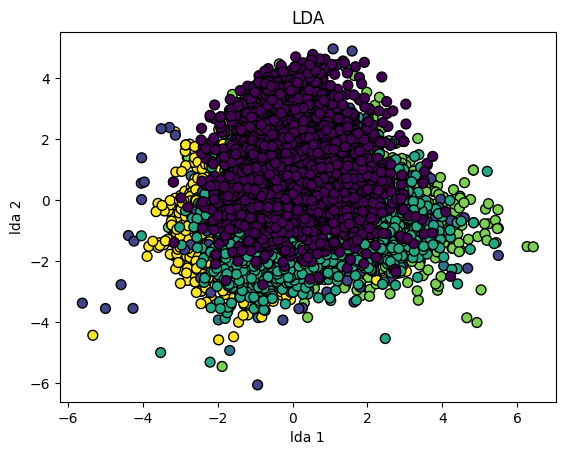

In [ ]:
plt.scatter(x_lda[:,0],x_lda[:,1],c=y_encoded,cmap="viridis",edgecolor="k",s=50)
plt.xlabel("lda 1")
plt.ylabel("lda 2")
plt.title("LDA")

# Independent component analysis (ICA)

Text(0.5, 1.0, 'ICA')

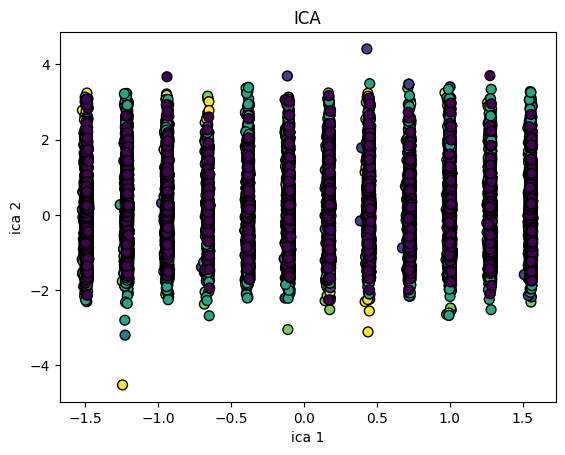

In [ ]:
ica = FastICA(n_components=2,algorithm='deflation')
x_ica = ica.fit_transform(X)
plt.scatter(x_ica[:,0],x_ica[:,1],c=y_encoded,cmap="viridis",edgecolor="k",s=50)
plt.xlabel("ica 1")
plt.ylabel("ica 2")
plt.title("ICA")